# 04 - Binary relevance y clasificación multietiqueta

Se reserva un 20% real como test multietiqueta. Con el 80% restante se entrena un clasificador one-vs-all por sistema cristalino (balanceado con SMOTE), y se evalúa en el test real.

In [1]:
from csp_perovskites import config, io, plotting, preprocessing as pp
from csp_perovskites import datasets as ds, evaluation as ev, models

## Parámetros

In [2]:
SCALER = "minmax"
TUNE = False      # True = GridSearchCV por sistema cristalino (mucho más lento)
MODELS = None     # None = los 12 modelos
N_JOBS = config.N_JOBS  # -1 = todos los núcleos; bajarlo si falta RAM; 1 = secuencial

df = pp.clean_master(io.load_master())
df_encoded = pp.encode_multilabel(df)
binary = ds.make_binary_splits(df_encoded, seed=config.RANDOM_STATE)
print("Etiquetas por compuesto en el test:", pp.label_cardinality(binary.Y_test).to_dict())

Etiquetas por compuesto en el test: {1: 919, 2: 97, 3: 27, 4: 9, 5: 4}


## Clasificación binaria por sistema cristalino

84 fits in parallel (n_jobs=-1)
  Cubic         Logistic Regression      acc=66.57%
  Tetragonal    Naive Bayes              acc=80.78%
  Cubic         Decision Tree            acc=81.06%
  Trigonal      Naive Bayes              acc=59.28%
  Orthorhombic  K-Nearest Neighbors      acc=77.94%
  Tetragonal    Logistic Regression      acc=82.58%
  Hexagonal     Naive Bayes              acc=87.88%
  Hexagonal     Logistic Regression      acc=86.84%
  Triclinic     Logistic Regression      acc=87.97%
  Cubic         Naive Bayes              acc=66.67%
  Monoclinic    Decision Tree            acc=96.50%
  Cubic         K-Nearest Neighbors      acc=78.03%
  Orthorhombic  Decision Tree            acc=75.95%
  Trigonal      K-Nearest Neighbors      acc=82.29%
  Orthorhombic  Naive Bayes              acc=65.15%
  Orthorhombic  Logistic Regression      acc=65.53%
  Tetragonal    K-Nearest Neighbors      acc=92.61%
  Triclinic     Naive Bayes              acc=84.66%
  Hexagonal     XGBoost         

,Cubic,Orthorhombic,Trigonal,Tetragonal,Monoclinic,Hexagonal,Triclinic
Logistic Regression,66.57,65.53,66.38,82.58,83.33,86.84,87.97
Naive Bayes,66.67,65.15,59.28,80.78,79.07,87.88,84.66
K-Nearest Neighbors,78.03,77.94,82.29,92.61,91.95,95.93,94.51
Decision Tree,81.06,75.95,87.97,94.51,96.50,97.54,97.54
Random Forest,85.13,84.56,92.80,97.25,97.73,98.96,98.20
Extra Trees,85.80,85.70,92.80,96.88,97.63,99.05,98.39
AdaBoost,79.26,78.22,87.78,95.17,96.21,98.39,97.25
Gradient Boosting,79.55,78.69,84.28,94.13,94.70,97.25,96.78
XGBoost,84.66,83.71,93.09,97.06,97.44,98.58,98.30
LightGBM,85.61,84.28,92.05,96.97,96.97,98.58,98.01


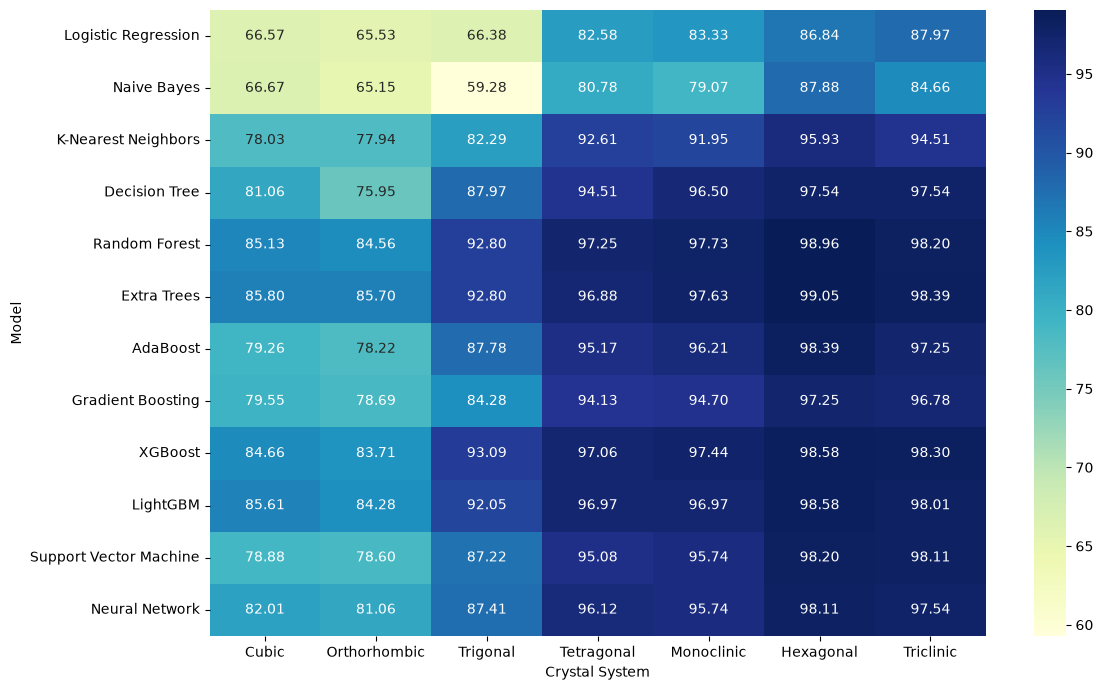

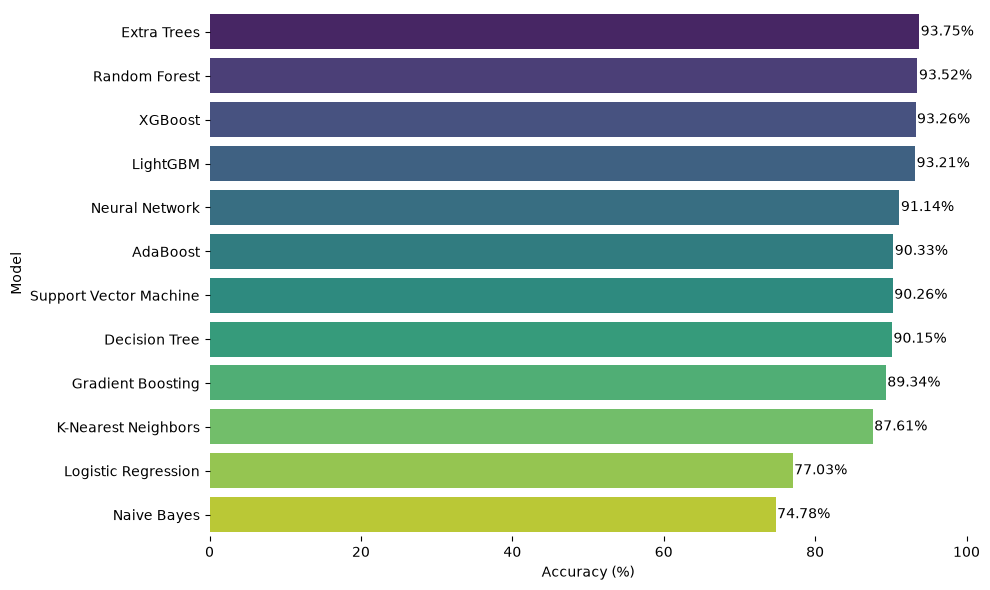

In [3]:
accuracy, predictions = ev.evaluate_binary(binary, models.get_classifiers(MODELS), scaler=SCALER, tune=TUNE,
                                           n_jobs=N_JOBS)
io.save_table(accuracy, "binary_accuracy.csv", index=True)

io.save_fig(plotting.accuracy_heatmap(accuracy), "crystal_system_accuracy.png")
io.save_fig(plotting.average_accuracy_bar(accuracy), "average_model_performance.png")
accuracy.round(2)

## Métricas multietiqueta (Extra Trees, LightGBM, Random Forest)

In [4]:
report = ev.multilabel_report(binary.Y_test, predictions, config.TOP_MODELS)
io.save_table(report, "multilabel_metrics.csv", index=True)
report.round(4)

,subset_accuracy,hamming_loss,label_accuracy,jaccard_samples,f1_micro,f1_macro
Random Forest,0.7064,0.0648,0.9352,0.7797,0.8055,0.5398
Extra Trees,0.7206,0.0625,0.9375,0.7913,0.8123,0.5147
LightGBM,0.6903,0.0679,0.9321,0.7753,0.7982,0.4826
